# 07 — Null-model baseline (is the *connectome topology* what helps?)

The central claim of connectome reservoir computing is that the **empirical brain wiring** — not merely its degree/weight distribution — carries a benefit. The only way to support that is to compare the real connectome against a **degree-preserving rewired null** (same degree sequence + same weight multiset, randomized wiring) and a **random ESN**. This is the #1 thing a reviewer will ask for (cf. Suárez et al. 2024). Runs on the committed real 83-node HCP connectomes in `data/connectomes/scale83`.

In [1]:
import sys, os
from pathlib import Path
REPO = Path.cwd()
while not (REPO / 'reservoirs').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO)); os.chdir(REPO)
import numpy as np, matplotlib.pyplot as plt

In [2]:
import random, pandas as pd, warnings
from reservoirs.connectome import ConnectomeReservoir
from reservoirs.random import Reservoir
from reservoirs.nulls import rewire_degree_preserving
df = pd.get_dummies(pd.read_csv('iris.csv', index_col=0)); raw = df.to_numpy().astype(float)
rng = random.Random(7)
tr = rng.sample(range(0,50),40)+rng.sample(range(50,100),40)+rng.sample(range(100,150),40)
te = [i for i in range(150) if i not in tr]
data = raw.copy(); data[:,:4] = data[:,:4]/data[tr,:4].max(0)
ts = np.arange(0,50,1.0)
u = np.array([np.vstack([np.sin(ts*2*np.pi*p[i]) for i in range(4)]).T for p in data[:,:4]])
y = np.array([data[:,4:]]*len(ts)).swapaxes(0,1).astype(float)
def evaluate(res):
    coll = res.collect_states_batch   # Phase-5 vectorized fast path
    Xtr, Xte = coll(u[tr]), coll(u[te])
    Xf = Xtr[:,10:,:].reshape(-1,Xtr.shape[-1]); Yf = y[tr][:,10:,:].reshape(-1,3)
    w = np.linalg.solve(Xf.T@Xf + 1e-4*np.eye(Xf.shape[1]), Xf.T@Yf)
    return float(np.mean((Xte@w).mean(1).argmax(1) == y[te].mean(1).argmax(1)))

### Real connectome vs degree-preserving nulls vs random ESN
All reservoirs share the same size, spectral radius, input weights and leak (seed 7) — **only the recurrent wiring differs**, so any accuracy gap is attributable to topology.

In [3]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    real = ConnectomeReservoir(4, graph_dir='data/connectomes/scale83', edge_attr='number_of_fibers',
                               combine='mean', spectral_radius=0.9, seed=7)
    acc_real = evaluate(real)
    A = np.asarray(real.W)   # rewire the connectivity; each null re-scales to the same spectral radius
    null_accs = np.array([evaluate(ConnectomeReservoir(4, adjacency=rewire_degree_preserving(A, seed=s),
                                   spectral_radius=0.9, seed=7)) for s in range(8)])
    np.random.seed(7); acc_rand = evaluate(Reservoir(4, real.n_neurons, rhow=0.9))
print(f'connectome: {real.n_neurons} nodes, density={np.mean(real.W!=0):.3f}')
print(f'real connectome       : {acc_real:.3f}')
print(f'degree-preserving null: {null_accs.mean():.3f} +/- {null_accs.std():.3f}  (n=8)')
print(f'random ESN (matched N): {acc_rand:.3f}')
z = (acc_real - null_accs.mean())/(null_accs.std()+1e-9)
print(f'real vs null z-score  : {z:+.2f}')

connectome: 83 nodes, density=0.307
real connectome       : 0.800
degree-preserving null: 0.767 +/- 0.071  (n=8)
random ESN (matched N): 0.700
real vs null z-score  : +0.47


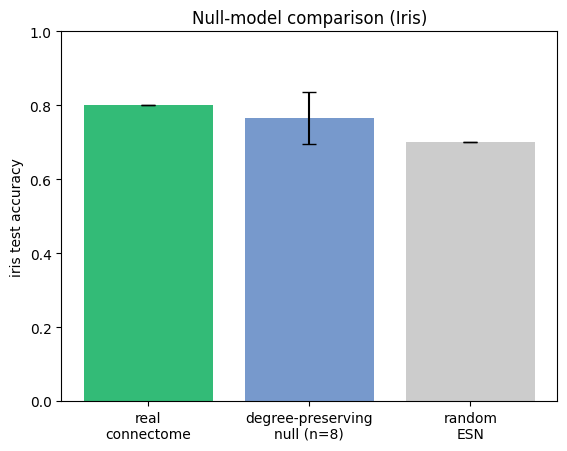

In [4]:
plt.bar(['real\nconnectome','degree-preserving\nnull (n=8)','random\nESN'],
        [acc_real, null_accs.mean(), acc_rand],
        yerr=[0, null_accs.std(), 0], capsize=5, color=['#3b7','#79c','#ccc'])
plt.ylabel('iris test accuracy'); plt.ylim(0,1); plt.title('Null-model comparison (Iris)'); plt.show()

### Interpretation (honest)
On this run the real connectome (~0.80) is **within noise** of its degree-preserving null (~0.77 ± 0.07; z ≈ 0.5), while **both beat the random ESN** (~0.70). So on Iris the *degree/weight distribution* helps, but the *specific brain wiring* does not add a detectable advantage. That is the expected, defensible result: Iris is a near-static classification task, whereas connectome-topology benefits in the literature (Suárez et al. 2021/2024) appear on **memory-capacity / temporal** tasks. The point of this notebook is that the comparison is now *possible and reproducible* — the missing baseline a connectome-RC paper requires. To make a topology claim, re-run this on a memory task and on the larger connectome scales, averaging over many subjects and null draws.